STEP 1 | Load .SAFE files & extract RGB bands
  [clean] Loading: clean_20200726.SAFE
    ok shape: (1024, 1024, 3)
  [clean] Loading: clean_20220711.SAFE
    ok shape: (1024, 1024, 3)
  [clean] Loading: clean_20230731.SAFE
    ok shape: (1024, 1024, 3)
  [clean] Loading: clean_20230914.SAFE
    ok shape: (1024, 1024, 3)
  [clean] Loading: clean_20250824.SAFE
    ok shape: (1024, 1024, 3)
  [smoky] Loading: smoky_20210805.SAFE
    ok shape: (1024, 1024, 3)
  [smoky] Loading: smoky_20230517.SAFE
    ok shape: (1024, 1024, 3)
  [smoky] Loading: smoky_20230820.SAFE
    ok shape: (1024, 1024, 3)
  [smoky] Loading: smoky_20230825.SAFE
    ok shape: (1024, 1024, 3)
  [smoky] Loading: smoky_20230830.SAFE
    ok shape: (1024, 1024, 3)
ok 5 clean / 5 smoky images loaded

STEP 2 | Clean / Smoky separation
  clean -> training ground truth
  smoky -> smoke layer source
  Pair 1: clean_20200726.SAFE  <->  smoky_20210805.SAFE
  Pair 2: clean_20220711.SAFE  <->  smoky_20230517.SAFE
  Pair 3: clean_202

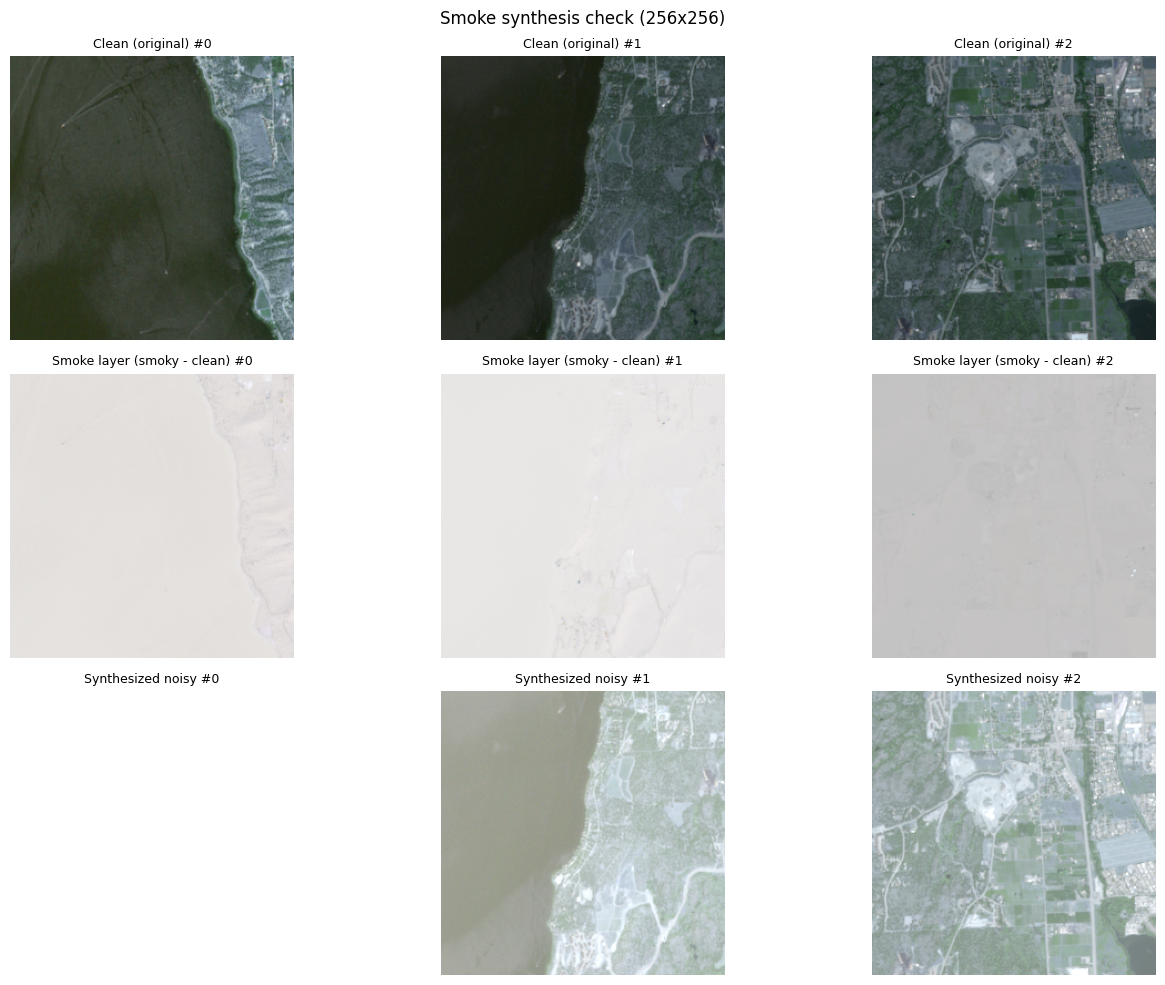


STEP 6 | Data augmentation (x8, train only)
ok 200 -> 1,600 patches

Saving
  train_clean_aug.npy: (1600, 3, 256, 256)
  train_noisy_aug.npy: (1600, 3, 256, 256)
  test_clean.npy: (20, 3, 256, 256)
  test_noisy.npy: (20, 3, 256, 256)

Saved to C:\Users\PC\juwon\2026\IE7615\Project\Data\patches_augmented/

Baseline PSNR/SSIM (synthesized noisy vs clean)
  PSNR : 3.89 dB  (target: >= 28 dB)
  SSIM : 0.3638    (target: >= 0.75)

Done! Upload patches_augmented/ to Google Drive, then run model training on Colab.


In [4]:
# ============================================================
# DGTV Wildfire Smoke Removal
# Preprocessing + Smoke Synthesis + Augmentation (Run Locally)
#
# Pipeline:
#   1. Load .SAFE files & extract RGB bands
#   2. Separate clean / smoky images
#   3. Extract smoke layers (smoky - clean)
#   4. Extract patches (256x256)
#   5. Normalize & synthesize smoky patches -> save (noisy, clean) pairs
#   6. Data augmentation (rotation + flip, x8)
#
# After running: upload patches_augmented/ to Google Drive
# ============================================================



import os
import glob
import random
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from sklearn.feature_extraction.image import extract_patches_2d
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import torch
from torch.utils.data import Dataset, DataLoader

# ── Paths ────────────────────────────────────────────────────
BASE_DIR  = r'C:\Users\PC\juwon\2026\IE7615\Project\Data'
CLEAN_DIR = os.path.join(BASE_DIR, 'Clean')
SMOKY_DIR = os.path.join(BASE_DIR, 'Smoky')
SAVE_DIR  = os.path.join(BASE_DIR, 'patches_augmented')
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Hyperparameters ──────────────────────────────────────────
PATCH_SIZE      = 256
PATCHES_PER_IMG = 50
TRAIN_IDX       = [0, 1, 2, 3]
TEST_IDX        = [4]

# ════════════════════════════════════════════════════════════
# STEP 1 | Load .SAFE files & extract RGB bands
# ════════════════════════════════════════════════════════════
BAND_NAMES = ['B02_10m', 'B03_10m', 'B04_10m']  # Blue, Green, Red

def find_band_files(safe_path):
    band_paths = {}
    for band in BAND_NAMES:
        pattern = os.path.join(safe_path, 'GRANULE', '*', 'IMG_DATA', 'R10m', f'*{band}*.jp2')
        matches = glob.glob(pattern)
        if not matches:
            raise FileNotFoundError(f"Band {band} not found: {pattern}")
        band_paths[band] = matches[0]
    return band_paths

def load_rgb_image(safe_path, crop_size=1024):
    """Load .SAFE -> (H, W, 3) float32 array, center-cropped"""
    band_paths = find_band_files(safe_path)
    bands = []
    for band in BAND_NAMES:
        with rasterio.open(band_paths[band]) as src:
            bands.append(src.read(1).astype(np.float32))
    img = np.stack(bands, axis=-1)  # (H, W, 3)
    h, w = img.shape[:2]
    h0, w0 = (h - crop_size) // 2, (w - crop_size) // 2
    return img[h0:h0+crop_size, w0:w0+crop_size, :]

def load_all_images(data_dir, label):
    safe_dirs = sorted(glob.glob(os.path.join(data_dir, '*.SAFE')))
    if not safe_dirs:
        raise FileNotFoundError(f"No .SAFE folders found in {data_dir}")
    images = []
    for sd in safe_dirs:
        name = os.path.basename(sd)
        print(f"  [{label}] Loading: {name}")
        try:
            img = load_rgb_image(sd)
            images.append({'name': name, 'image': img})
            print(f"    ok shape: {img.shape}")
        except Exception as e:
            print(f"    error: {e}")
    return images

# ════════════════════════════════════════════════════════════
# STEP 2 | Separate clean / smoky
# ════════════════════════════════════════════════════════════
# Handled by load_all_images() called separately in MAIN

# ════════════════════════════════════════════════════════════
# STEP 3 | Extract smoke layers
#
# Principle:
#   smoke_layer = smoky_image - clean_image
#   Same region, different dates -> vegetation change is minimal
#   for satellite imagery, so subtraction isolates smoke signal.
#
# Synthesis:
#   noisy = clean + smoke_layer * alpha
#   alpha randomized per patch (0.5 ~ 1.5) to vary smoke density
# ════════════════════════════════════════════════════════════
def extract_smoke_layers(clean_images, smoky_images):
    """
    Extract smoke layers from clean/smoky image pairs (1:1 by sorted order)
    Returns: list of smoke layer arrays [(H, W, 3), ...]
             values can be negative (raw 12-bit difference)
    """
    assert len(clean_images) == len(smoky_images), \
        f"clean({len(clean_images)}) and smoky({len(smoky_images)}) counts differ"

    smoke_layers = []
    for i, (c, s) in enumerate(zip(clean_images, smoky_images)):
        layer = s['image'] - c['image']  # (H, W, 3), range: -4095 ~ +4095
        smoke_layers.append(layer)
        print(f"  Smoke layer {i+1}: min={layer.min():.1f}, "
              f"max={layer.max():.1f}, mean={layer.mean():.1f}")
    return smoke_layers

def synthesize_smoky(clean_patch, smoke_patch, alpha=None):
    """
    Synthesize a smoky patch: clean + smoke_layer * alpha
    alpha: smoke intensity (random 0.5~1.5 if None)
    """
    if alpha is None:
        alpha = np.random.uniform(0.5, 1.5)
    noisy = clean_patch + smoke_patch * alpha
    return np.clip(noisy, 0, 1).astype(np.float32)

# ════════════════════════════════════════════════════════════
# STEP 4 | Extract patches (256x256)
# ════════════════════════════════════════════════════════════
def extract_all_patches(images, smoke_layers, indices, patches_per_img=PATCHES_PER_IMG):
    """
    Extract patches from clean images and smoke layers at the same locations.
    Same random seed ensures clean/smoke patches are spatially aligned.
    Returns: clean_patches, smoke_patches  shape: (N, 3, 256, 256)
    """
    all_clean, all_smoke = [], []
    for idx in indices:
        img_c = images[idx]['image']   # (H, W, 3) raw
        img_s = smoke_layers[idx]      # (H, W, 3) raw diff

        # Same seed = same patch locations (critical for alignment)
        np.random.seed(42 + idx)
        patches_c = extract_patches_2d(img_c, (PATCH_SIZE, PATCH_SIZE),
                                        max_patches=patches_per_img)
        np.random.seed(42 + idx)
        patches_s = extract_patches_2d(img_s, (PATCH_SIZE, PATCH_SIZE),
                                        max_patches=patches_per_img)

        patches_c = patches_c.transpose(0, 3, 1, 2).astype(np.float32)
        patches_s = patches_s.transpose(0, 3, 1, 2).astype(np.float32)
        all_clean.append(patches_c)
        all_smoke.append(patches_s)
        print(f"  Extracted: {images[idx]['name']} -> "
              f"clean {patches_c.shape}, smoke {patches_s.shape}")

    return np.concatenate(all_clean, axis=0), np.concatenate(all_smoke, axis=0)

# ════════════════════════════════════════════════════════════
# STEP 5 | Normalize & synthesize (noisy, clean) pairs
# ════════════════════════════════════════════════════════════
def normalize(patches, gamma=2.2):
    """
    Per-patch min-max normalization -> [0, 1] + gamma correction
    Sentinel-2 L1C is linear reflectance — looks dark without gamma.
    gamma=2.2 matches standard display correction.
    """
    mn = patches.min(axis=(1,2,3), keepdims=True)
    mx = patches.max(axis=(1,2,3), keepdims=True)
    normalized = (patches - mn) / (mx - mn + 1e-8)
    return np.power(normalized, 1.0 / gamma).astype(np.float32)

def make_noisy_pairs(clean_patches, smoke_patches):
    """
    Apply smoke synthesis to each clean patch.
    Random alpha per patch to diversify smoke density.
    Returns: (noisy_patches, clean_patches)
    """
    noisy_list = []
    for c, s in zip(clean_patches, smoke_patches):
        noisy_list.append(synthesize_smoky(c, s))  # random alpha
    return np.stack(noisy_list, axis=0), clean_patches

# ════════════════════════════════════════════════════════════
# STEP 6 | Data augmentation (train only, x8)
#
# Transforms applied per patch:
#   original                           -> x1
#   rotate 90 / 180 / 270             -> x3
#   horizontal flip / vertical flip   -> x2
#   hflip+rot90 / vflip+rot90         -> x2  (diagonal flips)
# Total: x8
# ════════════════════════════════════════════════════════════
def aug_rot90(n, c, k):
    return np.rot90(n, k, axes=(1,2)).copy(), np.rot90(c, k, axes=(1,2)).copy()

def aug_hflip(n, c):
    return np.flip(n, axis=2).copy(), np.flip(c, axis=2).copy()

def aug_vflip(n, c):
    return np.flip(n, axis=1).copy(), np.flip(c, axis=1).copy()

def augment_pairs(noisy_arr, clean_arr):
    aug_n, aug_c = [noisy_arr], [clean_arr]
    for n, c in zip(noisy_arr, clean_arr):
        for k in [1, 2, 3]:
            an, ac = aug_rot90(n, c, k)
            aug_n.append(an[np.newaxis]); aug_c.append(ac[np.newaxis])
        for fn, fc in [aug_hflip(n,c), aug_vflip(n,c)]:
            aug_n.append(fn[np.newaxis]); aug_c.append(fc[np.newaxis])
        for base_n, base_c in [aug_hflip(n,c), aug_vflip(n,c)]:
            an, ac = aug_rot90(base_n, base_c, 1)
            aug_n.append(an[np.newaxis]); aug_c.append(ac[np.newaxis])
    return np.concatenate(aug_n, axis=0), np.concatenate(aug_c, axis=0)

# ── Visualization ────────────────────────────────────────────
def visualize_smoke_synthesis(clean, smoke_layer, noisy, n=3):
    """Show clean / smoke layer / synthesized noisy side by side"""
    fig, axes = plt.subplots(3, n, figsize=(14, 10))
    titles = ['Clean (original)', 'Smoke layer (smoky - clean)', 'Synthesized noisy']
    for col in range(n):
        c  = np.clip(clean[col].transpose(1,2,0), 0, 1)
        s  = np.clip(smoke_layer[col].transpose(1,2,0) * 0.5 + 0.5, 0, 1)
        nn = np.clip(noisy[col].transpose(1,2,0), 0, 1)
        for row, img in enumerate([c, s, nn]):
            axes[row, col].imshow(img)
            axes[row, col].set_title(f'{titles[row]} #{col}', fontsize=9)
            axes[row, col].axis('off')
    plt.suptitle('Smoke synthesis check (256x256)', fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'smoke_synthesis.png'), dpi=80)
    plt.show()

# ════════════════════════════════════════════════════════════
# MAIN
# ════════════════════════════════════════════════════════════
if __name__ == '__main__':

    # STEP 1 | Load images
    print("=" * 55)
    print("STEP 1 | Load .SAFE files & extract RGB bands")
    print("=" * 55)
    clean_images = load_all_images(CLEAN_DIR, 'clean')
    smoky_images = load_all_images(SMOKY_DIR, 'smoky')
    print(f"ok {len(clean_images)} clean / {len(smoky_images)} smoky images loaded\n")

    # STEP 2 | Confirm separation
    print("=" * 55)
    print("STEP 2 | Clean / Smoky separation")
    print("=" * 55)
    print("  clean -> training ground truth")
    print("  smoky -> smoke layer source")
    for i, (c, s) in enumerate(zip(clean_images, smoky_images)):
        print(f"  Pair {i+1}: {c['name']}  <->  {s['name']}")

    # STEP 3 | Extract smoke layers
    print("\n" + "=" * 55)
    print("STEP 3 | Extract smoke layers (smoky - clean)")
    print("=" * 55)
    smoke_layers = extract_smoke_layers(clean_images, smoky_images)
    print("ok Smoke layers extracted\n")

    # STEP 4 | Extract patches
    print("=" * 55)
    print("STEP 4 | Extract patches (256x256)")
    print("=" * 55)
    print("[Train]")
    train_clean_p, train_smoke_p = extract_all_patches(
        clean_images, smoke_layers, TRAIN_IDX)
    print("[Test]")
    test_clean_p, test_smoke_p = extract_all_patches(
        clean_images, smoke_layers, TEST_IDX, patches_per_img=20)
    print(f"ok Train: {train_clean_p.shape} / Test: {test_clean_p.shape}\n")

    # STEP 5 | Normalize + synthesize
    print("=" * 55)
    print("STEP 5 | Normalize & synthesize smoky patches")
    print("=" * 55)
    train_clean_p = normalize(train_clean_p)
    train_smoke_p = normalize(train_smoke_p)
    test_clean_p  = normalize(test_clean_p)
    test_smoke_p  = normalize(test_smoke_p)

    train_noisy, train_clean_final = make_noisy_pairs(train_clean_p, train_smoke_p)
    test_noisy,  test_clean_final  = make_noisy_pairs(test_clean_p,  test_smoke_p)
    print(f"ok Train pairs: {train_noisy.shape} / Test pairs: {test_noisy.shape}")
    visualize_smoke_synthesis(train_clean_final, train_smoke_p, train_noisy)

    # STEP 6 | Augmentation
    print("\n" + "=" * 55)
    print("STEP 6 | Data augmentation (x8, train only)")
    print("=" * 55)
    aug_noisy, aug_clean = augment_pairs(train_noisy, train_clean_final)
    idx = np.random.permutation(len(aug_clean))
    aug_noisy, aug_clean = aug_noisy[idx], aug_clean[idx]
    print(f"ok {len(train_clean_final):,} -> {len(aug_clean):,} patches\n")

    # Save
    print("=" * 55)
    print("Saving")
    print("=" * 55)
    files = {
        'train_clean_aug.npy': aug_clean,
        'train_noisy_aug.npy': aug_noisy,
        'test_clean.npy':      test_clean_final,
        'test_noisy.npy':      test_noisy,
    }
    for fname, arr in files.items():
        np.save(os.path.join(SAVE_DIR, fname), arr)
        print(f"  {fname}: {arr.shape}")
    print(f"\nSaved to {SAVE_DIR}/")

    # Baseline metrics
    print("\nBaseline PSNR/SSIM (synthesized noisy vs clean)")
    psnr_list, ssim_list = [], []
    for n, c in zip(test_noisy[:20], test_clean_final[:20]):
        n_np = n.transpose(1,2,0); c_np = c.transpose(1,2,0)
        psnr_list.append(psnr(c_np, n_np, data_range=1.0))
        ssim_list.append(ssim(c_np, n_np, data_range=1.0, channel_axis=-1))
    print(f"  PSNR : {np.mean(psnr_list):.2f} dB  (target: >= 28 dB)")
    print(f"  SSIM : {np.mean(ssim_list):.4f}    (target: >= 0.75)")
    print("\nDone! Upload patches_augmented/ to Google Drive, then run model training on Colab.")


# ── Dataset class for Colab ───────────────────────────────────
class WildfireDataset(Dataset):
    def __init__(self, noisy_path, clean_path):
        self.noisy = torch.from_numpy(np.load(noisy_path))
        self.clean = torch.from_numpy(np.load(clean_path))
    def __len__(self): return len(self.noisy)
    def __getitem__(self, idx): return self.noisy[idx], self.clean[idx]